# Image Compression with Low-Rank Approximations

This notebook compares low-rank approximation methods from **librla** on RGB images:

1. **Randomized SVD** (`svd_sketch`)
2. **Interpolative Decomposition** (`id_sketch`)
3. **Randomized SVD** with oversampling and power iteration
4. **ID** with oversampling and power iteration
5. **QR with column pivoting** (`qr_sketch`)

The image is reshaped to a 2D matrix (m x 3n) for processing.

ID selects k skeleton columns and expresses remaining columns as
linear combinations: `A[:, piv[k:]] = A[:, piv[:k]] @ T`

**Prerequisites:** Run `download_images.py` first to obtain test images.

Try changing the **Configuration** parameters below to experiment!

In [21]:
# Configuration - Modify these to experiment

#IMAGE_FILE = 'hello_world.png'         # Image to compress (bw)
#IMAGE_FILE = 'lorem_ipsum.png'         # Image to compress (bw)
IMAGE_FILE = 'pexels-flickr-149387.jpg'         # Image to compress (gray)
#IMAGE_FILE = 'pexels-anniroenkae-4793404.jpg'   # Image to compress (rgb)
TARGET_RANK = 60                                # Rank of approximation
USE_SINGLE = True                               # True for single precision (faster, less memory)

In [22]:
import sys
import os
import time
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
from PIL import Image

# Add parent directory to path for librla
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('')), 'python'))
import librla

# Load image
A = np.array(Image.open(IMAGE_FILE))
m, n, nc = A.shape
print(f'Image: {IMAGE_FILE}')
print(f'Size: {m} x {n} x {nc}')
print(f'Target rank: {TARGET_RANK}')
print(f'Precision: {"single" if USE_SINGLE else "double"}')

Image: pexels-flickr-149387.jpg
Size: 4016 x 6016 x 3
Target rank: 60
Precision: single


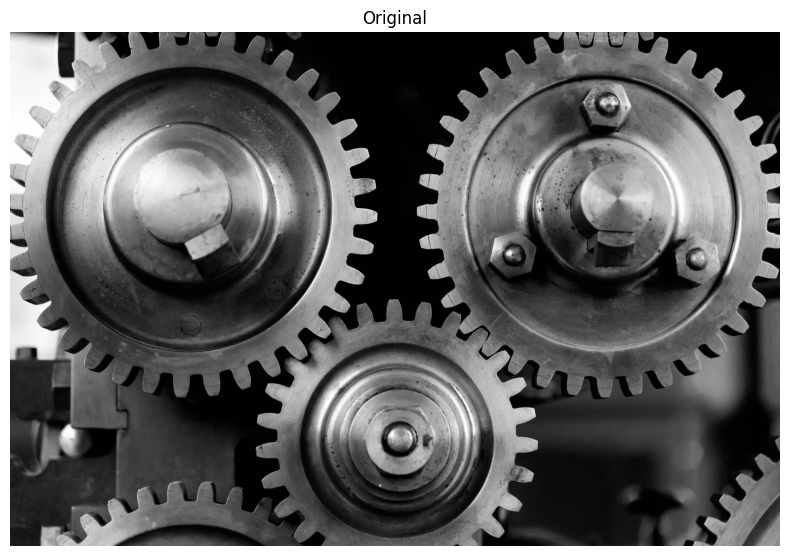

In [23]:
# Display original image
plt.figure(figsize=(8, 6))
plt.imshow(A)
plt.title('Original')
plt.axis('off')
plt.tight_layout()

In [24]:
# Reshape RGB image to 2D matrix: m x (n*nc)
k = TARGET_RANK
conv = np.float32 if USE_SINGLE else np.float64
A2 = conv(A).reshape(m, n * nc)
print(f'Reshaped matrix: {A2.shape[0]} x {A2.shape[1]}, dtype: {A2.dtype}')

Reshaped matrix: 4016 x 18048, dtype: float32


## Method 1: Randomized SVD

svd_sketch(k=60): 0.082s, error 1.682548e-01


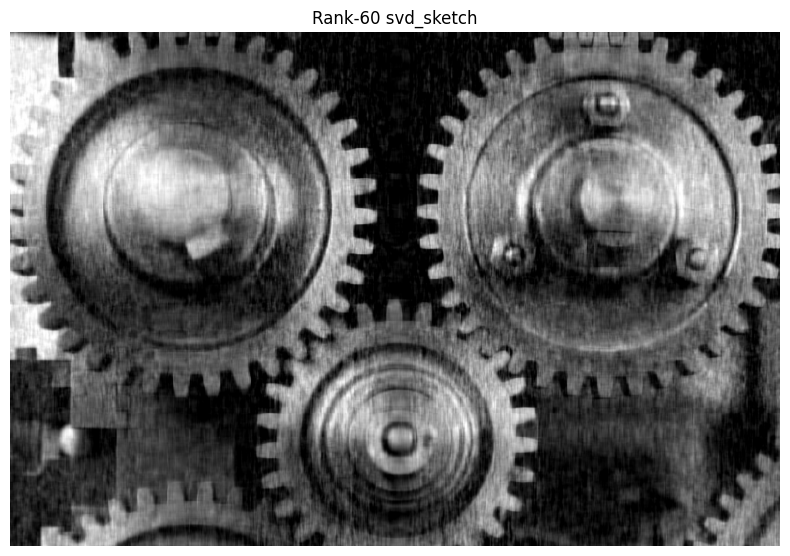

In [25]:
t0 = time.time()
U, s, Vh = librla.svd_sketch(A2, k)
B2_svd = U @ np.diag(s) @ Vh
elapsed_svd = time.time() - t0

B_svd = B2_svd.reshape(m, n, nc)
rel_error_svd = norm(A2 - B2_svd, 'fro') / norm(A2, 'fro')
print(f'svd_sketch(k={k}): {elapsed_svd:.3f}s, error {rel_error_svd:.6e}')

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(B_svd, 0, 255).astype(np.uint8))
plt.title(f'Rank-{k} svd_sketch')
plt.axis('off')
plt.tight_layout()

## Method 2: Interpolative Decomposition

ID selects k skeleton columns and expresses remaining columns as linear combinations:
```
A[:, piv[k:]] = A[:, piv[:k]] @ T
```

id_sketch(k=60): 0.061s, error 2.343212e-01


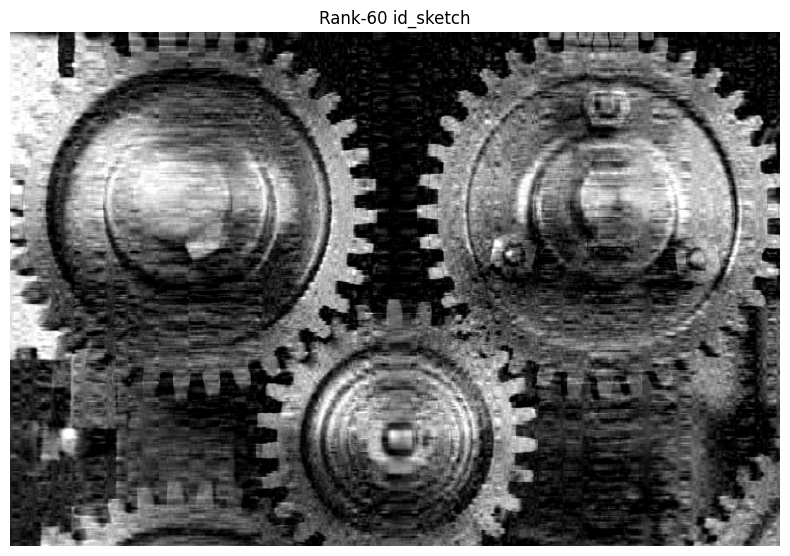

In [26]:
t0 = time.time()
k_id, piv, T = librla.id_sketch(A2, k)
elapsed_id = time.time() - t0

# Reconstruct: skeleton columns + interpolated columns
skeleton = A2[:, piv[:k_id]]
interpolated = skeleton @ T

# Unpermute to original column order
B2_id = np.zeros_like(A2)
B2_id[:, piv[:k_id]] = skeleton
B2_id[:, piv[k_id:]] = interpolated

B_id = B2_id.reshape(m, n, nc)
rel_error_id = norm(A2 - B2_id, 'fro') / norm(A2, 'fro')
print(f'id_sketch(k={k_id}): {elapsed_id:.3f}s, error {rel_error_id:.6e}')

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(B_id, 0, 255).astype(np.uint8))
plt.title(f'Rank-{k_id} id_sketch')
plt.axis('off')
plt.tight_layout()

## Method 3: SVD with oversampling and power iteration

svd_sketch(k=60, extra_samples=30, power_iter=2): 0.110s, error 1.153168e-01


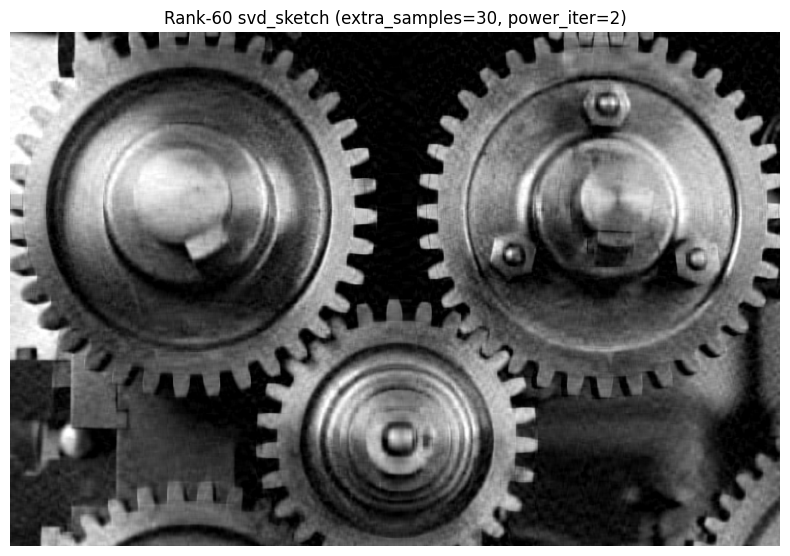

In [27]:
extra = k // 2  # 50% oversampling
piter = 2       # power iterations

t0 = time.time()
U3, s3, Vh3 = librla.svd_sketch(A2, k, extra_samples=extra, power_iter=piter)
B2_svd2 = U3 @ np.diag(s3) @ Vh3
elapsed_svd2 = time.time() - t0

B_svd2 = B2_svd2.reshape(m, n, nc)
rel_error_svd2 = norm(A2 - B2_svd2, 'fro') / norm(A2, 'fro')
print(f'svd_sketch(k={k}, extra_samples={extra}, power_iter={piter}): {elapsed_svd2:.3f}s, error {rel_error_svd2:.6e}')

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(B_svd2, 0, 255).astype(np.uint8))
plt.title(f'Rank-{k} svd_sketch (extra_samples={extra}, power_iter={piter})')
plt.axis('off')
plt.tight_layout()

## Method 4: ID with oversampling and power iteration

id_sketch(k=60, extra_samples=30, power_iter=2): 0.129s, error 1.793904e-01


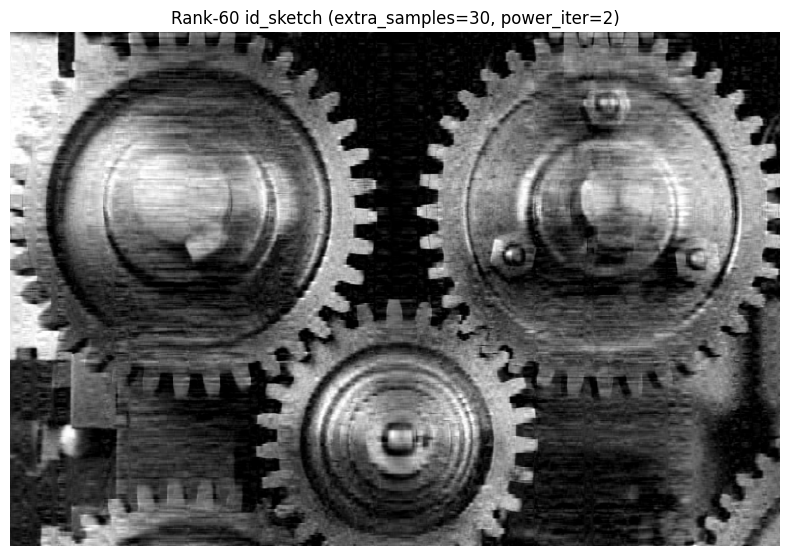

In [28]:
t0 = time.time()
k_id2, piv2, T2 = librla.id_sketch(A2, k, extra_samples=extra, power_iter=piter)
elapsed_id2 = time.time() - t0

# Reconstruct
skeleton2 = A2[:, piv2[:k_id2]]
interpolated2 = skeleton2 @ T2

B2_id2 = np.zeros_like(A2)
B2_id2[:, piv2[:k_id2]] = skeleton2
B2_id2[:, piv2[k_id2:]] = interpolated2

B_id2 = B2_id2.reshape(m, n, nc)
rel_error_id2 = norm(A2 - B2_id2, 'fro') / norm(A2, 'fro')
print(f'id_sketch(k={k_id2}, extra_samples={extra}, power_iter={piter}): {elapsed_id2:.3f}s, error {rel_error_id2:.6e}')

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(B_id2, 0, 255).astype(np.uint8))
plt.title(f'Rank-{k_id2} id_sketch (extra_samples={extra}, power_iter={piter})')
plt.axis('off')
plt.tight_layout()

## Method 5: QR with column pivoting

qr_sketch(k=60, extra_samples=30, power_iter=2): 0.123s, error 1.438560e-01


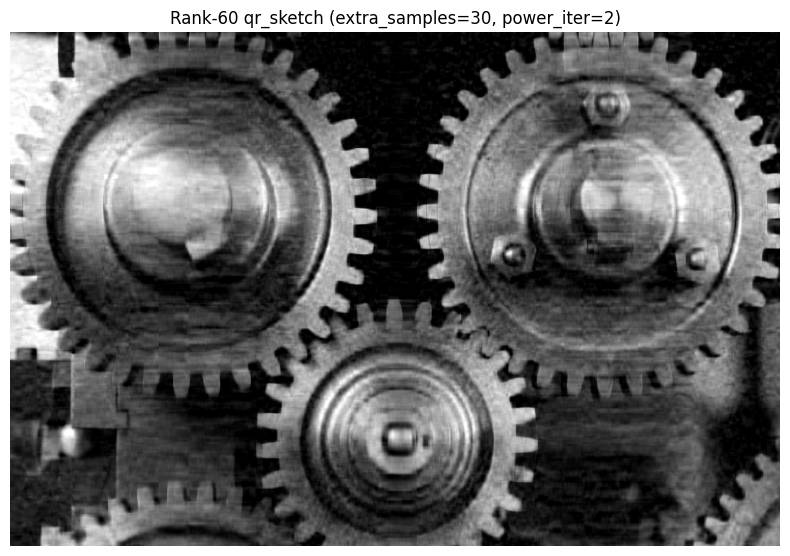

In [29]:
t0 = time.time()
Q_qr, R_qr, p_qr = librla.qr_sketch(A2, k, extra_samples=extra, power_iter=piter)
elapsed_qr = time.time() - t0

k_qr = Q_qr.shape[1]

# Reconstruct: A[:, p] = Q @ R, so unpermute columns
B2_qr_perm = Q_qr @ R_qr
B2_qr = np.zeros_like(A2)
B2_qr[:, p_qr] = B2_qr_perm

B_qr = B2_qr.reshape(m, n, nc)
rel_error_qr = norm(A2 - B2_qr, 'fro') / norm(A2, 'fro')
print(f'qr_sketch(k={k_qr}, extra_samples={extra}, power_iter={piter}): {elapsed_qr:.3f}s, error {rel_error_qr:.6e}')

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(B_qr, 0, 255).astype(np.uint8))
plt.title(f'Rank-{k_qr} qr_sketch (extra_samples={extra}, power_iter={piter})')
plt.axis('off')
plt.tight_layout()

## Summary

In [30]:
print(f'{"Method":<40} {"Rank":>4}    {"Error"}')
print('-' * 55)
print(f'{"svd_sketch(k=" + str(k) + ")":<40} {k:4d}    {rel_error_svd:.6e}')
print(f'{"id_sketch(k=" + str(k_id) + ")":<40} {k_id:4d}    {rel_error_id:.6e}')
print(f'{"svd_sketch(k=" + str(k) + ", extra, power)":<40} {k:4d}    {rel_error_svd2:.6e}')
print(f'{"id_sketch(k=" + str(k_id2) + ", extra, power)":<40} {k_id2:4d}    {rel_error_id2:.6e}')
print(f'{"qr_sketch(k=" + str(k_qr) + ", extra, power)":<40} {k_qr:4d}    {rel_error_qr:.6e}')

Method                                   Rank    Error
-------------------------------------------------------
svd_sketch(k=60)                           60    1.682548e-01
id_sketch(k=60)                            60    2.343212e-01
svd_sketch(k=60, extra, power)             60    1.153168e-01
id_sketch(k=60, extra, power)              60    1.793904e-01
qr_sketch(k=60, extra, power)              60    1.438560e-01
